# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv 


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж 
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели. 

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

## 1. Импорт библиотек и функций

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def onehot_encoding(x):
    unique_values = np.sort(np.unique(x))
    new_arr = np.zeros((len(x), len(unique_values)), dtype=int)
    for i in range(len(x)):
        column_idx = np.where(unique_values == x[i])[0][0]
        new_arr[i, column_idx] = 1
    return new_arr

def apply_minmax(X, mn, mx):
    diff = mx - mn
    diff[diff == 0] = 1
    return (X - mn) / diff

## 2. Загрузка, анализ и обработка данных

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv')
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41


In [3]:
df.info()
# Видим большое кол-во NAN в Gender, что ставит под сомнение использование данной фичи

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB


In [4]:
df['Claim'].value_counts()
# Видим явный дизбаланс классов

Claim
No     62399
Yes      927
Name: count, dtype: int64

In [5]:
df['Distribution Channel'].unique()
# Всего 2 уникальных значения, сохраним данный признак

array(['Offline', 'Online'], dtype=object)

In [6]:
df['Destination'].unique()
# Слишком большое кол-во уникальных значений, будем сохранять признак,
# но дополнительно сделаем преобразования, чтобы уменьшить кол-во признаков

array(['MALAYSIA', 'AUSTRALIA', 'ITALY', 'UNITED STATES', 'THAILAND',
       "KOREA, DEMOCRATIC PEOPLE'S REPUBLIC OF", 'NORWAY', 'VIET NAM',
       'DENMARK', 'SINGAPORE', 'JAPAN', 'UNITED KINGDOM', 'INDONESIA',
       'INDIA', 'CHINA', 'FRANCE', 'TAIWAN, PROVINCE OF CHINA',
       'PHILIPPINES', 'MYANMAR', 'HONG KONG', 'KOREA, REPUBLIC OF',
       'UNITED ARAB EMIRATES', 'NAMIBIA', 'NEW ZEALAND', 'COSTA RICA',
       'BRUNEI DARUSSALAM', 'POLAND', 'SPAIN', 'CZECH REPUBLIC',
       'GERMANY', 'SRI LANKA', 'CAMBODIA', 'AUSTRIA', 'SOUTH AFRICA',
       'TANZANIA, UNITED REPUBLIC OF', "LAO PEOPLE'S DEMOCRATIC REPUBLIC",
       'NEPAL', 'NETHERLANDS', 'MACAO', 'CROATIA', 'FINLAND', 'CANADA',
       'TUNISIA', 'RUSSIAN FEDERATION', 'GREECE', 'BELGIUM', 'IRELAND',
       'SWITZERLAND', 'CHILE', 'ISRAEL', 'BANGLADESH', 'ICELAND',
       'PORTUGAL', 'ROMANIA', 'KENYA', 'GEORGIA', 'TURKEY', 'SWEDEN',
       'MALDIVES', 'ESTONIA', 'SAUDI ARABIA', 'PAKISTAN', 'QATAR', 'PERU',
       'LUXEMBOURG',

In [7]:
df['Agency'].value_counts()
# Категориальных фич немного, можем сохранить данный признак

Agency
EPX    35119
CWT     8580
C2B     8267
JZI     6329
SSI     1056
JWT      749
RAB      725
LWC      689
TST      528
KML      392
ART      331
CCR      194
CBH      101
TTW       98
CSR       86
ADM       82
Name: count, dtype: int64

<Axes: xlabel='Net Sales', ylabel='Commision (in value)'>

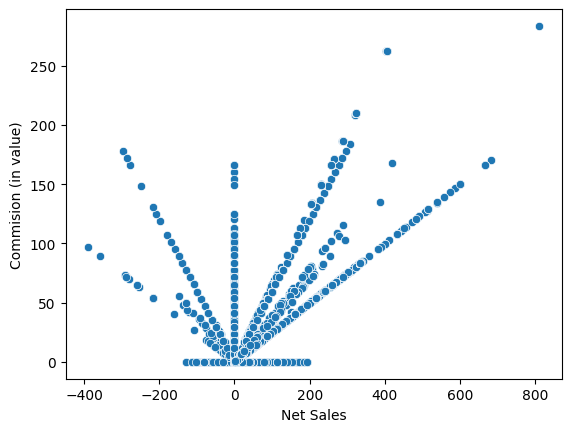

In [8]:
sns.scatterplot(x = df['Net Sales'], y = df['Commision (in value)'])
# Явных аномалий не наблюдается

In [9]:
df[(df['Duration'] > 365) | (df['Duration'] < 0)]['Duration'].unique()
# Видны явные аномалии (кол-во дней поездки,больше года/или вообще отрицательное)

array([ 388,  369,  368,  374,  386,  367,  366,  431,  370,  403,  392,
        397,  378, 4881,  391,  390,  389,  375,  385,  371,  387,  376,
        377,  417,  406, 4857,  373,  432,  419,  400,  381, 4847, 4844,
        380,  384,  382,  407, 4831, 4829,  383,  427,  740,   -2, 4815,
        395,  372,  399,  379,  411, 4784,  402,  436,  409,  547,  396,
        457,  393,  394,  401,  426,  487,  408,  398, 4738, 4736,  421,
        456,  416,  440,  529,  461,  418,  420,  404,  428,  413, 4685,
        430, 4652,  448,  465,  478,  497,  405,  422,  545,  508,  412,
        415,  437,  474,  441, 4609,  459,   -1,  435,  472,  410,  424,
        531,  434, 4580,  490,  494,  466,  512,  519,  444,  423,  425,
        445,  414,  463,  433,  450,  488])

In [10]:
# Оставляем нужные колонки, Gender удалили из-за большого кол-ва NAN, 
# Product Name не несёт смыслового значения + тяжело обрабатываемый признак
keep_cols = ['Agency', 'Net Sales', 'Duration', 'Destination', 'Age', 'Claim', 'Agency Type', 'Distribution Channel']
df = df[keep_cols]

In [11]:
# Разделяем на x,y
X = df.drop('Claim', axis=1)
y = df['Claim'].map({'Yes': 1, 'No': 0})

In [12]:
# Сплит, чтобы избежать утечки данных и брать статистики только из train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=112)

In [13]:
# Удаляем подозрительно большой/отрицательный Duration только из Train, и фиксируем медиану,
# чтобы заменить аномалии на тестовой выборке, тк удалять сэмплы из тестовой выборки, не всегда хорошая идея,
# тот же Kaggle не потерпит такого решения
bad_dur_idx_train = X_train[(X_train['Duration'] > 365) | (X_train['Duration'] < 0)].index
X_train = X_train.drop(bad_dur_idx_train)
y_train = y_train.drop(bad_dur_idx_train)

dur_median = X_train['Duration'].median()

bad_dur_idx_test = X_test[(X_test['Duration'] > 365) | (X_test['Duration'] < 0)].index
X_test.loc[bad_dur_idx_test, 'Duration'] = dur_median

In [14]:
# Замена Age медианой из Train
med_age = X_train['Age'].median()
for d in [X_train, X_test]:
    d.loc[(d['Age'] > 100) | (d['Age'] < 0), 'Age'] = med_age

In [15]:
# Кол-во категориальных переменнных в колонке Destination слишком большое, поэтому возьмем
# 10 наиболее часто встречающихся в Train, а остальное пометим как Other и изменим это в Train и Test
top_countries = X_train['Destination'].value_counts().nlargest(10).index
X_train['Destination'] = X_train['Destination'].apply(lambda x: x if x in top_countries else 'Other')
X_test['Destination'] = X_test['Destination'].apply(lambda x: x if x in top_countries else 'Other')

In [16]:
# Выполняем масштабирование, фиксируем числовые признаки, 
# берем макс/мин значения исключительно из Train
# чтобы избежать утечку данных, и применяем масштабирование
num_cols = ['Net Sales', 'Duration', 'Age']
X_train_num = X_train[num_cols].values
X_test_num = X_test[num_cols].values

mn_train = X_train_num.min(axis=0)
mx_train = X_train_num.max(axis=0)

X_train_num_scaled = apply_minmax(X_train_num,mn_train,mx_train)
X_test_num_scaled = apply_minmax(X_test_num, mn_train, mx_train)

In [17]:
# Кодируем категориальные фичи one-hot-encoderom,
# чтобы избежать утечки данных, структура колонок для Test формируется строго на основе уникальных категорий из Train.
cat_cols = ['Agency', 'Destination', 'Agency Type', 'Distribution Channel']
X_train_cat_list = []
X_test_cat_list = []

for col in cat_cols:
    train_enc = onehot_encoding(X_train[col].values)
    X_train_cat_list.append(train_enc)
    
    categories = np.sort(X_train[col].unique())
    test_enc_final = np.zeros((len(X_test), len(categories)))
    
    current_test_vals = X_test[col].values
    for i, cat in enumerate(categories):
        test_enc_final[:, i] = (current_test_vals == cat).astype(int)
    
    X_test_cat_list.append(test_enc_final)

In [18]:
# Собираем финальные матрицы признаков + добавляем bias
X_train_concat = np.hstack([X_train_num_scaled] + X_train_cat_list)
X_test_concat = np.hstack([X_test_num_scaled] + X_test_cat_list)

bias_train = np.ones((X_train_concat.shape[0], 1))
bias_test = np.ones((X_test_concat.shape[0], 1))

X_train_final = np.hstack([bias_train, X_train_concat])
X_test_final = np.hstack([bias_test, X_test_concat])

print(f"Размерность Обучающей выборки: {X_train_final.shape}")
print(f"Размерность Тестовой выборки: {X_test_final.shape}")

Размерность Обучающей выборки: (49617, 35)
Размерность Тестовой выборки: (12666, 35)


In [19]:
# Выполним downsampling(случайно берем такое же кол-во сэмплов мажоритарного класса, чтобы сравниться с миноритарным) 
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

np.random.seed(112)
downsampled_idx_0 = np.random.choice(idx_0, size=len(idx_1), replace=False)

balanced_idx = np.concatenate([downsampled_idx_0, idx_1])

X_train_balanced = X_train_final[balanced_idx]
y_train_balanced = y_train.iloc[balanced_idx] 

print(f"Размерность Обучающей выборки после downsampling: X:{X_train_balanced.shape}, y:{y_train_balanced.shape}")
print(np.unique_counts(y_train_balanced))

Размерность Обучающей выборки после downsampling: X:(1310, 35), y:(1310,)
UniqueCountsResult(values=array([0, 1]), counts=array([655, 655]))


### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2. 

## 3. Нахождение Аналитического решения

In [20]:
# Находим аналитическое решение
lambd = 10

num_of_features = X_train_final.shape[1]
E = np.eye(num_of_features)
E[0,0] = 0 # не штрафуем bias

inverse_matrix = np.linalg.pinv(np.dot(X_train_balanced.T, X_train_balanced)) # используем pinv, чтобы не словить ошибку о необратимости матрицы
inverse_matrix_l2 = np.linalg.inv(np.dot(X_train_balanced.T, X_train_balanced) + lambd * E)

weights = np.dot(np.dot(inverse_matrix,X_train_balanced.T),y_train_balanced)
weights_l2 = np.dot(np.dot(inverse_matrix_l2, X_train_balanced.T),y_train_balanced)

In [21]:
# Посчитаем значения вручную
y_raw = np.dot(X_test_final, weights.T)
y_raw_l2 = np.dot(X_test_final,weights_l2.T)

y_pred = np.round(np.clip(y_raw, 0, 1))
y_pred_l2 = np.round(np.clip(y_raw_l2, 0, 1))

Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

##  4. LinearRegression + Метрики

In [22]:
model = LinearRegression()
model.fit(X_train_balanced, y_train_balanced)

raw_predictions = model.predict(X_test_final)
y_pred_model = np.round(np.clip(raw_predictions, 0, 1))

mse_model = mean_squared_error(y_test, y_pred_model)
print(f"MSE_MODEL: {mse_model}")

MSE_MODEL: 0.1633507026685615


In [23]:
# Сравним с метриками MSE, которые были получены в ходе ручного решения
mse = mean_squared_error(y_test, y_pred)
mse_l2 = mean_squared_error(y_test, y_pred_l2)

print(f"MSE: {mse}")
print(f"MSE_L2: {mse_l2}")

MSE: 0.1633507026685615
MSE_L2: 0.16271909047844624


In [24]:
# Дополнительно глянем на метрики, которые используются в задачах классификации, 
# тк MSE не всегда позволяет точно понять конечный результат, используем classification_report
print("Ручное аналитическое решение")
print(classification_report(y_test,y_pred))
print('\n\n\n\n')

print("Ручное аналитическое решение с l2 регуляризацией")
print(classification_report(y_test,y_pred_l2))
print('\n\n\n\n')

print("Модель LinearRegression")
print(classification_report(y_test,y_pred_model))
print('\n\n\n\n')

Ручное аналитическое решение
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     12492
           1       0.06      0.72      0.11       174

    accuracy                           0.84     12666
   macro avg       0.53      0.78      0.51     12666
weighted avg       0.98      0.84      0.90     12666






Ручное аналитическое решение с l2 регуляризацией
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     12492
           1       0.06      0.70      0.11       174

    accuracy                           0.84     12666
   macro avg       0.53      0.77      0.51     12666
weighted avg       0.98      0.84      0.90     12666






Модель LinearRegression
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     12492
           1       0.06      0.72      0.11       174

    accuracy                           0.84     12666
   macro avg    

### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?

### Вывод по работе

* **Предотвращение утечки:** Разделение на обучающую и тестовую выборки выполнено до этапа обработки признаков. Все статистики (медианы для заполнения пропусков, параметры для скейлеров) вычислялись только на `train`-выборке
* **Очистка данных:** Выполнена фильтрация аномальных значений в признаках `Duration` и `Age`
* **Снижение размерности:** Для признака `Destination` применено группирование: оставлены топ-10 стран, остальные помечены как `Other`, что позволило сократить количество уникальных фичей, чтобы при one-hot-encoding это не вылилось в большое кол-во признаков
* **Балансировка классов (Downsampling):** Ввиду явного дисбаланса, обучение на полных данных привело бы к тому, что модель всегда предсказывала бы 0 для минимизации MSE, что было бы ничем не лучше чем обычный константный классификатор.
* **Аналитическое решение:** Реализовано нахождение весов через матричные операции (параметр lambda для L2 подбирался экспериментально, тк по ТЗ не указано, что можно юзать `GridSearchCv`) и модель `LinearRegression` из sklearn. Результаты совпали с моделью `LinearRegression` из `sklearn`, что подтверждает правильность проделанной работы
* **Метрики:** Итоговое значение **MSE** на тестовой выборке составило **~0.163**
* **Классификация:** Несмотря на использование линейной регрессии в задачи классификации, модель демонстрирует высокую полноту (**Recall = 0.72**). Это означает, что алгоритм успешно находит большинство страховых случаев, что было бы невозможно без предварительной балансировки классов
* **Использование `clip`**: Так как модель предсказывает непрерывное значение, может возникнуть ситуация при которой обычное округление получит значение, не являющееся нашим классом, то есть ни 1, ни 0. Чтобы предотвратить это использовался `clip`, чтобы втянуть значения в нужный диапазон.